# Tuần 07 — Thực hành DBSCAN: 3 bài

Demo `07_Demo-DBSCAN.ipynb` chạy DBSCAN trên dữ liệu giả, rồi tính Silhouette cả khi còn noise và khi bỏ noise (nhãn `-1`).

File này có **3 bài**, cùng 3 bộ Kaggle với `06_TH-kMeans.ipynb`. Cả 3 bài đều làm. Dùng `sklearn.cluster.DBSCAN`.

DBSCAN không nhận `K`. Hai tham số là `eps` và `min_samples`. Nhãn `-1` là nhiễu, không phải một cụm.

Fit `StandardScaler` trên toàn bộ feature. `eps` đọc trên dữ liệu **đã chuẩn hóa**.

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## Phần chung

Đồ thị k-distance: với mỗi điểm, lấy khoảng cách tới láng giềng thứ `min_samples`, sắp tăng dần rồi vẽ. `eps` nằm ở chỗ đường bắt đầu dựng đứng.

Silhouette chỉ tính khi còn ít nhất 2 cụm. Bản "bỏ noise" loại các điểm nhãn `-1` trước, giống mục 2.3 của demo.


In [2]:
def ve_k_distance(X_scaled, min_samples=5):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_scaled)
    dists, _ = nn.kneighbors(X_scaled)
    kth = np.sort(dists[:, -1])
    plt.figure(figsize=(6, 4))
    plt.plot(kth)
    plt.xlabel('điểm, đã sắp theo khoảng cách')
    plt.ylabel(f'khoảng cách tới láng giềng thứ {min_samples}')
    plt.grid(True)
    plt.show()
    return kth


def tom_tat(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    cum = [c for c in np.unique(labels) if c != -1]
    print('số cụm:', len(cum))
    print('số nhiễu:', n_noise)
    print(np.unique(labels, return_counts=True))


def silhouette_hai_cach(X_scaled, labels):
    labels = np.asarray(labels)
    cum = [c for c in np.unique(labels) if c != -1]
    if len(cum) < 2:
        print('Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.')
        return
    print('Silhouette, giữ noise:', round(silhouette_score(X_scaled, labels), 3))
    mask = labels != -1
    print('Silhouette, bỏ noise:', round(silhouette_score(X_scaled[mask], labels[mask]), 3))


---

# Bài 1 — Khách hàng trung tâm thương mại

Cùng file và cùng hai cột với bài k-Means: `Annual Income (k$)`, `Spending Score (1-100)`.

Chuẩn hóa, vẽ k-distance với `min_samples=5`, chọn `eps` ở khuỷu. Fit DBSCAN. Vẽ scatter: cụm tô màu, nhiễu để màu đen dấu `x`.

Gợi ý khi chỉnh: ra toàn `-1` thì tăng `eps`. Ra đúng 1 cụm và không còn nhiễu thì giảm `eps`. Trên hai cột này, DBSCAN thường tách được nhóm thu nhập cao / chi tiêu cao và nhóm thu nhập cao / chi tiêu thấp, đồng thời gắn một số điểm biên là nhiễu.


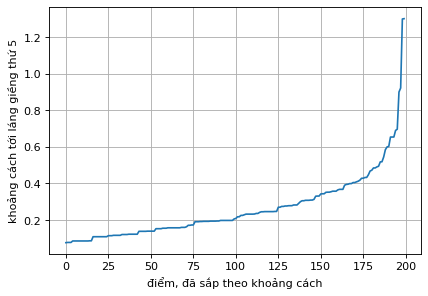

In [3]:
mall = pd.read_csv('data/Mall_Customers.csv')
cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

kth = ve_k_distance(X_scaled, min_samples=5)

số cụm: 6
số nhiễu: 23
(array([-1,  0,  1,  2,  3,  4,  5]), array([23, 16, 12,  7, 88, 31, 23]))
Silhouette, giữ noise: 0.437
Silhouette, bỏ noise: 0.558


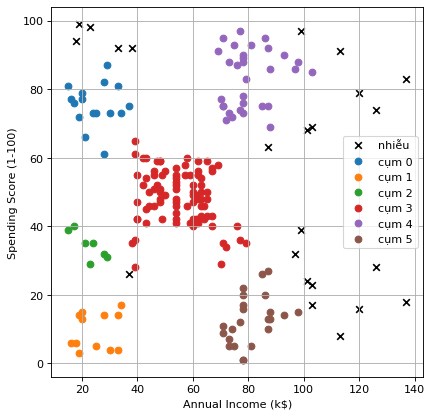

In [4]:
# TODO: đọc eps từ đồ thị k-distance
eps = 0.35
min_samples = 5
labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    if cum == -1:
        plt.scatter(pts[:, 0], pts[:, 1], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

silhouette_hai_cach(X_scaled, labels)

**Nộp kèm bài 1**

1. `eps` và `min_samples` bạn dùng? Có bao nhiêu cụm, bao nhiêu điểm nhiễu?
2. So với k-Means trên cùng hai cột: điểm khác nhìn thấy trên hình là gì?
3. Silhouette khi giữ noise và khi bỏ noise, số nào cao hơn? Vì sao demo cũng tính lại sau khi bỏ noise?


In [5]:
# Bài 1
# 1. min_samples = 5, eps = 0.35 (đọc ở khuỷu của đồ thị k-distance, nơi đường bắt đầu dựng đứng).
#    Kết quả: 6 cụm (88, 31, 23, 16, 12, 7 điểm) và 23 điểm nhiễu (11.5% trong 200 khách).
# 2. K-Means (K=5) gán mọi khách vào đúng một cụm nên không có nhiễu, ranh giới cụm chia đều.
#    DBSCAN trên hình: tách rõ hai cụm thu nhập cao là cao/chi tiêu cao (31 khách) và
#    cao/chi tiêu thấp (23 khách), nhưng chia nhóm thu nhập thấp thành 3 cụm nhỏ
#    (16, 12 và 7 khách), và gắn 23 điểm nằm ở rìa / vùng thưa giữa các cụm là nhiễu (x đen).
#    Số cụm không cần chọn trước mà do mật độ quyết định.
# 3. Silhouette giữ noise = 0.437, bỏ noise = 0.558, bỏ noise cao hơn. Điểm nhiễu không thuộc
#    cụm nào, nằm ở vùng thưa nên có hệ số Silhouette thấp, kéo trung bình xuống. Demo tính lại
#    sau khi bỏ noise để đánh giá chất lượng của các cụm thật, nhưng cần báo kèm tỉ lệ nhiễu.

---

# Bài 2 — Quốc gia

Cùng file `Country-data.csv`. Bỏ cột `country` khỏi `X`, chuẩn hóa 9 cột số.

Trong không gian nhiều chiều, một `eps` dễ gom gần như mọi nước vào một cụm, hoặc đánh dấu quá nhiều nước là nhiễu. Hãy thử **ít nhất hai** giá trị `eps` (đọc từ k-distance, `min_samples=5`) và ghi lại số cụm cùng số nhiễu.

Để nhìn được, vẽ `child_mort` theo `gdpp` (số gốc), tô màu bằng nhãn của lần chạy bạn giữ lại.


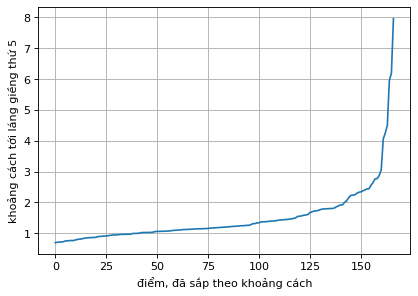

In [6]:
country = pd.read_csv('data/Country-data.csv')
cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

kth = ve_k_distance(X_scaled, min_samples=5)

--- eps = 1.0
số cụm: 3
số nhiễu: 94
(array([-1,  0,  1,  2]), array([94, 52, 16,  5]))
--- eps = 1.2
số cụm: 3
số nhiễu: 53
(array([-1,  0,  1,  2]), array([53, 21, 75, 18]))
--- eps = 1.5
số cụm: 1
số nhiễu: 30
(array([-1,  0]), array([ 30, 137]))
--- eps = 2.0
số cụm: 1
số nhiễu: 15
(array([-1,  0]), array([ 15, 152]))
=== eps giữ lại ===
số cụm: 3
số nhiễu: 53
(array([-1,  0,  1,  2]), array([53, 21, 75, 18]))
một số nước bị coi là nhiễu: ['Angola', 'Bahrain', 'Belarus', 'Belgium', 'Botswana', 'Brunei', 'Burundi', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.']


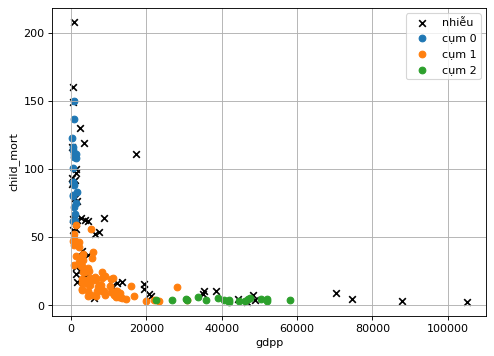

In [7]:
# TODO: thử ít nhất 2 eps, in tom_tat cho mỗi lần
for e in [1.0, 1.2, 1.5, 2.0]:
    print('--- eps =', e)
    tom_tat(DBSCAN(eps=e, min_samples=5).fit_predict(X_scaled))

# Giữ lại một eps để vẽ
print('=== eps giữ lại ===')
eps = 1.2
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)
print('một số nước bị coi là nhiễu:', country.loc[labels == -1, 'country'].head(10).tolist())

plt.figure(figsize=(7, 5))
for cum in np.unique(labels):
    pts = country.loc[labels == cum]
    if cum == -1:
        plt.scatter(pts['gdpp'], pts['child_mort'], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts['gdpp'], pts['child_mort'], label=f'cụm {cum}')
plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.legend()
plt.grid(True)
plt.show()

**Nộp kèm bài 2**

1. Hai giá trị `eps` bạn thử, và số cụm / số nhiễu của mỗi lần?
2. `eps` bạn giữ lại gắn những nước nào vào nhiễu? Kể 3 tên.
3. Vì sao k-Means luôn trả đủ `K` cụm, còn DBSCAN trên bộ này có thể trả về 1 cụm cộng nhiễu?


In [8]:
# Bài 2
# 1. min_samples = 5. eps = 1.0: 3 cụm, 94 nhiễu. eps = 1.2: 3 cụm, 53 nhiễu.
#    eps = 1.5: 1 cụm, 30 nhiễu. eps = 2.0: 1 cụm, 15 nhiễu.
# 2. Giữ lại eps = 1.2 (3 cụm: 75, 21, 18 nước, và 53 nước nhiễu). Một số nước bị coi là nhiễu:
#    Angola, Bahrain, Burundi (còn Belgium, Brunei, Central African Republic, ...).
#    Nhiễu nằm ở cả hai phía: nước rất nghèo (Burundi) và nước giàu / dầu mỏ (Bahrain, Brunei).
#    Trên hình child_mort theo gdpp, ba cụm lần lượt là: nhóm gdpp thấp - child_mort cao,
#    nhóm trung bình và nhóm gdpp cao - child_mort thấp.
# 3. K-Means buộc mọi điểm thuộc một trong K cụm do ta chọn, nên luôn trả đủ K cụm. DBSCAN chỉ
#    tạo cụm ở vùng đủ dày (>= min_samples điểm trong bán kính eps). Với 9 chiều đã chuẩn hóa,
#    167 nước phân bố khá liên tục, không có khoảng trống rõ giữa các nhóm: khi eps đủ lớn
#    (1.5 trở lên) các vùng dày nối vào nhau thành 1 cụm, còn vài nước cô lập thành nhiễu.

---

# Bài 3 — Khách sỉ

Cùng 6 cột chi tiêu với bài k-Means. Không đưa `Channel` và `Region` vào `X`. Chuẩn hóa.

Chi tiêu có vài khách rất lớn so với phần còn lại. DBSCAN thường gắn họ là nhiễu (`-1`) thay vì kéo tâm cụm đi, khác k-Means.

Chọn `eps` bằng k-distance (`min_samples=5`). In số cụm, số nhiễu, Silhouette hai cách, và `crosstab` giữa nhãn với `Channel`.


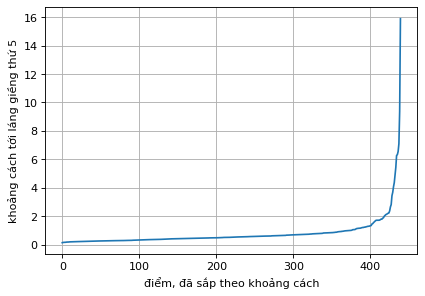

In [9]:
import os
duong_dan_ws = 'data/Wholesale customers data.csv'
if not os.path.exists(duong_dan_ws):        # file tải về có thể tên Wholesale_customers_data.csv
    duong_dan_ws = 'data/Wholesale_customers_data.csv'
ws = pd.read_csv(duong_dan_ws)
cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

kth = ve_k_distance(X_scaled, min_samples=5)

In [10]:
eps = 0.6
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)
silhouette_hai_cach(X_scaled, labels)
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))

số cụm: 3
số nhiễu: 131
(array([-1,  0,  1,  2]), array([131, 297,   7,   5]))
Silhouette, giữ noise: 0.129
Silhouette, bỏ noise: 0.379
Channel    1   2
cum             
-1        64  67
 0       229  68
 1         5   2
 2         0   5


**Nộp kèm bài 3**

1. `eps` bạn chọn? Bao nhiêu điểm bị coi là nhiễu?
2. Nhãn `-1` có nằm dồn ở một `Channel` không?
3. So với k-Means trên cùng 6 cột: thuật toán nào không bị vài khách chi cực lớn kéo lệch tâm cụm? Giải thích bằng cách mỗi thuật toán tạo cụm.


In [11]:
# Bài 3
# 1. min_samples = 5, eps = 0.6 (khuỷu của k-distance nằm khoảng 0.5 - 0.8; chọn 0.6 để còn
#    ít nhất 2 cụm thì mới tính được Silhouette). Kết quả: 3 cụm (297, 7, 5 khách) và 131 nhiễu
#    (29.8% trong 440 khách). Silhouette giữ noise = 0.129, bỏ noise = 0.379.
# 2. Nhãn -1 không dồn vào một kênh: 64 Horeca và 67 Retail. Tuy vậy so với tỉ lệ chung
#    (298 Horeca, 142 Retail) thì Retail bị gắn nhiễu nhiều hơn (67/142 = 47%, trong khi
#    Horeca là 64/298 = 21%). Khách nhiễu chi cao hơn hẳn cụm chính (Grocery trung bình 15031 so
#    với 4735), tức đây là nhóm khách chi lớn nằm ở vùng thưa.
# 3. DBSCAN không bị khách chi cực lớn kéo lệch. Cụm của DBSCAN được tạo từ các điểm lõi dày
#    đặc và những điểm nối với chúng; khách chi cực lớn nằm xa, không đủ láng giềng trong eps,
#    nên thành nhiễu (-1) và không tham gia xác định cụm. K-Means thì bắt mọi điểm phải thuộc
#    một cụm và tâm cụm là trung bình các điểm, nên vài khách chi cực lớn kéo tâm lệch
#    hoặc phải chiếm riêng một cụm nhỏ (K=3 ở bài k-Means có cụm 13 khách chi cực lớn).